# Flow Sample Diagnostics

Focused notebook for cached-sample diagnostics using hierarchical cache layout from [scr]_tf_analysis.py.

In [1]:
import json
import os
import sys
from os.path import join

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from utils import density_contour, img_to_gal_axis, make_corner_plot, make_g_contour

In [28]:
# Configure these paths and identifiers for your run
cache_root = '/ocean/projects/phy250048p/shared/cache'
fig_root = '/ocean/projects/phy250048p/shared/figures'
sample_csv = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'

model_name = 'CNN-CNN-flow'
dataset_name = 'valid_1m'
os.makedirs(join(fig_root, model_name), exist_ok=True)
partitions = [f'part{i}of10' for i in range(10)]

# 0 -> mode 1 (no TF prior), 1 -> mode 2 (with TF prior)
mode_index = 0
vcirc_idx = 5

In [31]:
data_types = [
                # 'sample', 
                # 'log_prob', 
                'snr', 
                'truth', 
                'map_estimates', 
                # 'mean_estimates', 
                'meta'
            ]

def cache_path(data_type, partition, ext='npy'):
    if data_type not in data_types:
        raise ValueError(f'Unsupported data type: {data_type}')
    return join(cache_root, model_name, dataset_name, data_type, f'{partition}.{ext}')

def load_partition(data_types, partition):
    sample_path = cache_path('sample', partition) if 'sample' in data_types else None
    log_prob_path = cache_path('log_prob', partition) if 'log_prob' in data_types else None
    snr_path = cache_path('snr', partition) if 'snr' in data_types else None
    truth_path = cache_path('truth', partition) if 'truth' in data_types else None
    map_path = cache_path('map_estimates', partition) if 'map_estimates' in data_types else None
    mean_path = cache_path('mean_estimates', partition) if 'mean_estimates' in data_types else None
    meta_path = cache_path('meta', partition, ext='json') if 'meta' in data_types else None

    path_list = [sample_path, log_prob_path, snr_path, truth_path, map_path, mean_path, meta_path]
    required = [p for p in path_list if p is not None]
    missing = [p for p in required if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError('Missing hierarchical cache files for partition '
                                f"{partition}: {missing}")

    with open(meta_path, 'r', encoding='ascii') as fp:
        meta = json.load(fp)

    print('Loaded partition', partition, 'with meta:', meta)

    return {
        'partition': partition,
        'sample': np.load(sample_path) if sample_path else None,
        'log_prob': np.load(log_prob_path) if log_prob_path else None,
        'snr': np.load(snr_path) if snr_path else None,
        'truth': np.load(truth_path) if truth_path else None,
        'map_estimates': np.load(map_path) if map_path else None,
        'mean_estimates': np.load(mean_path) if mean_path else None,
        'meta': meta,
    }

In [34]:
parts = [load_partition(data_types, p) for p in partitions]

samples = np.concatenate([p['sample'] for p in parts], axis=1) if 'sample' in data_types else None
log_probs = np.concatenate([p['log_prob'] for p in parts], axis=1) if 'log_prob' in data_types else None
snrs = np.concatenate([p['snr'] for p in parts], axis=0) if 'snr' in data_types else None
truths = np.concatenate([p['truth'] for p in parts], axis=0) if 'truth' in data_types else None
map_estimates = np.concatenate([p['map_estimates'] for p in parts], axis=1) if 'map_estimates' in data_types else None
mean_estimates = np.concatenate([p['mean_estimates'] for p in parts], axis=1) if 'mean_estimates' in data_types else None

ngals = truths.shape[0]

assert samples.shape[1] == ngals if samples is not None else True
assert log_probs.shape[1] == ngals if log_probs is not None else True
assert snrs.shape[0] == ngals if snrs is not None else True
assert map_estimates.shape[1] == ngals if map_estimates is not None else True
assert mean_estimates.shape[1] == ngals if mean_estimates is not None else True

# print('samples', samples.shape)
# print('log_probs', log_probs.shape)
# print('snrs', snrs.shape)
# print('truths', truths.shape)
# print('map_estimates', map_estimates.shape)
# print('mean_estimates', mean_estimates.shape)

Loaded partition part0of10 with meta: {'model_name': 'CNN-CNN-flow', 'dataset_name': 'valid_1m', 'partition_index': 0, 'total_partitions': 10, 'partition_label': 'part0of10', 'mode': 0, 'model_mode': 1, 'nsamples': 10000, 'galaxy_range': {'start': 0, 'end': 10000}, 'paths': {'d4_diff': 'd4_diff/part0of10.npy', 'd4_truth': 'd4_truth/part0of10.npy', 'd4_pred': 'd4_pred/part0of10.npy'}, 'status': 'success', 'created_at_utc': '2026-05-27T23:41:48.419553+00:00', 'args': {'stem': 'CNN-CNN-flow', 'dataset': 'valid_1m', 'sample_set': 'samples_valid_1m.csv', 'cache_root': '/ocean/projects/phy250048p/shared/cache'}}
Loaded partition part1of10 with meta: {'model_name': 'CNN-CNN-flow', 'dataset_name': 'valid_1m', 'partition_index': 1, 'total_partitions': 10, 'partition_label': 'part1of10', 'mode': 0, 'model_mode': 1, 'nsamples': 10000, 'galaxy_range': {'start': 10000, 'end': 20000}, 'paths': {'d4_diff': 'd4_diff/part1of10.npy', 'd4_truth': 'd4_truth/part1of10.npy', 'd4_pred': 'd4_pred/part1of10.np

In [35]:
sample_table = pd.read_csv(sample_csv)
theta = np.array(sample_table['theta_int'])[:ngals]
if theta.shape[0] != ngals:
    raise ValueError(f'theta length mismatch: {theta.shape[0]} vs {ngals}')

g1_true = truths[:, 0]
g2_true = truths[:, 1]
vcirc_true = truths[:, vcirc_idx]

g1_pred = map_estimates[mode_index, :, 0]
g2_pred = map_estimates[mode_index, :, 1]
vcirc_pred = map_estimates[mode_index, :, vcirc_idx]

g1_diff = g1_pred - g1_true
g2_diff = g2_pred - g2_true
vcirc_diff = vcirc_pred - vcirc_true

gp_true, gc_true = img_to_gal_axis(g1_true, g2_true, theta)
gp_pred, gc_pred = img_to_gal_axis(g1_pred, g2_pred, theta)
gp_diff = gp_pred - gp_true
gc_diff = gc_pred - gc_true

In [81]:
g2_bin_centers = np.arange(-0.1, 0.1, 0.02) + 0.01
g2_bin_edges = np.arange(-0.1, 0.1 + 0.01, 0.02)
g2_bin_indices = np.digitize(g2_true, g2_bin_edges) - 1
g1_diff_avgs = np.array([g1_diff[g2_bin_indices == i].mean() for i in range(len(g2_bin_centers))])
g1_diff_errs = np.array([g1_diff[g2_bin_indices == i].std() / np.sqrt((g2_bin_indices == i).sum()) for i in range(len(g2_bin_centers))])
g2_diff_avgs = np.array([g2_diff[g2_bin_indices == i].mean() for i in range(len(g2_bin_centers))])
g2_diff_errs = np.array([g2_diff[g2_bin_indices == i].std() / np.sqrt((g2_bin_indices == i).sum()) for i in range(len(g2_bin_centers))])

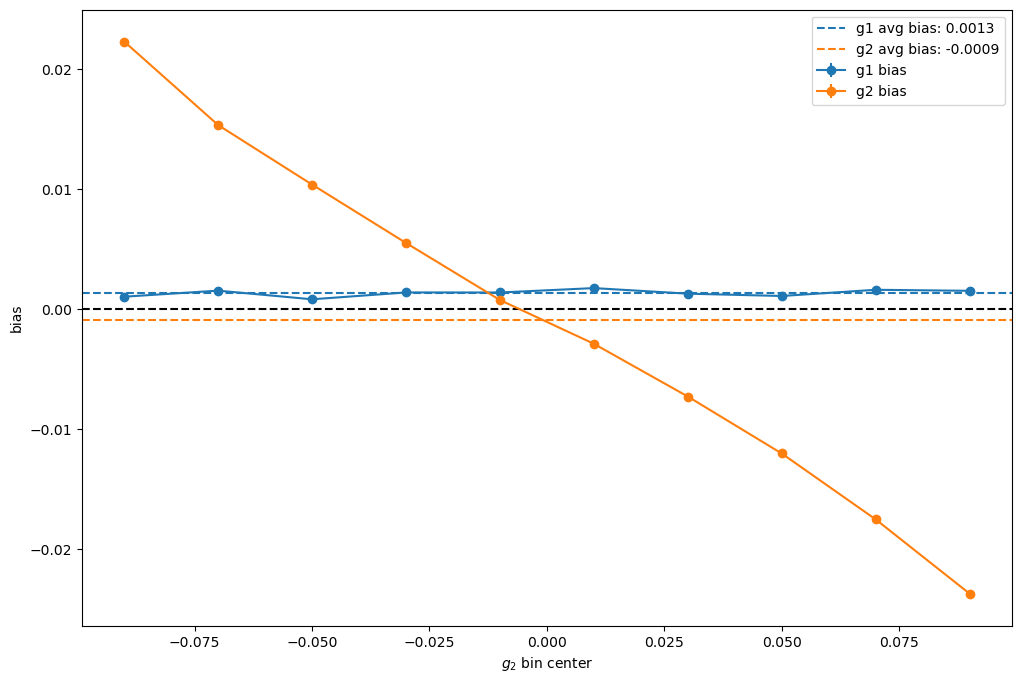

In [82]:
plt.figure(figsize=(12, 8))
plt.errorbar(g2_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(g2_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$g_2$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_g2.png'), dpi=300, bbox_inches='tight')
plt.show()

In [43]:
theta_bin_centers = np.arange(-np.pi, np.pi, np.pi/8)+np.pi/16
theta_bin_edges = np.arange(-np.pi, np.pi+1e-6, np.pi/8)
theta_bin_indices = np.digitize(theta, theta_bin_edges) - 1

In [44]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(16):
    g1_diff_bin = g1_diff[theta_bin_indices == i]
    g2_diff_bin = g2_diff[theta_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

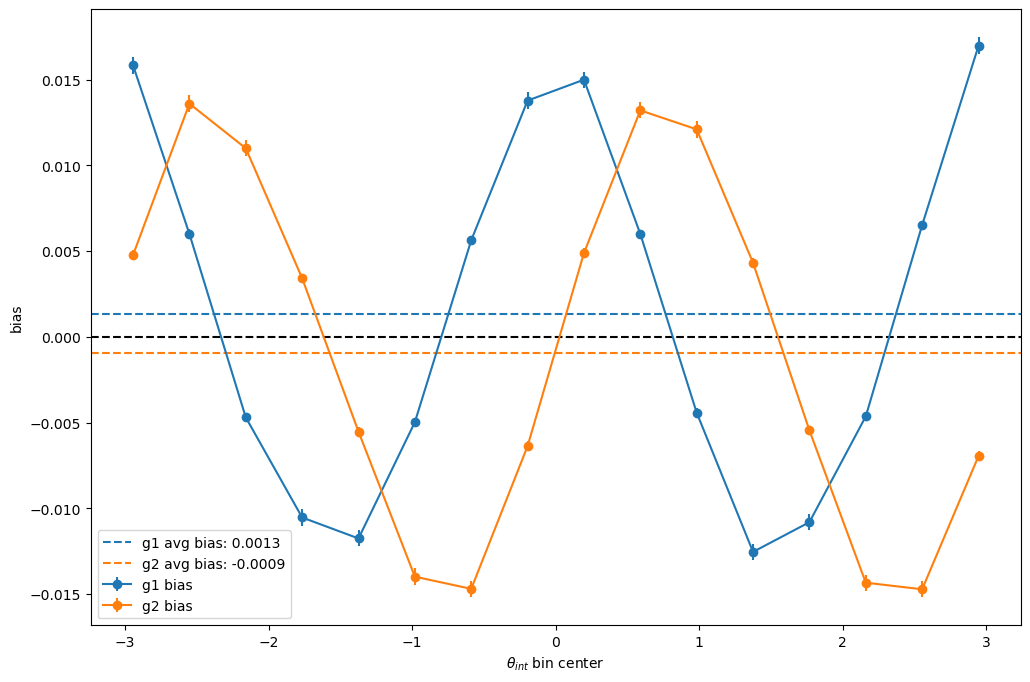

In [46]:
plt.figure(figsize=(12, 8))
plt.errorbar(theta_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(theta_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\theta_{int}$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_theta.png'), dpi=300, bbox_inches='tight')
plt.show()

In [60]:
sin_theta_bin_centers = np.arange(-1, 1, 0.1)+0.05
sin_theta_bin_edges = np.arange(-1, 1.01, 0.1)
sin_theta_bin_indices = np.digitize(np.sin(theta), sin_theta_bin_edges) - 1
cos_theta_bin_centers = np.arange(-1, 1, 0.1)+0.05
cos_theta_bin_edges = np.arange(-1, 1.01, 0.1)
cos_theta_bin_indices = np.digitize(np.cos(theta), cos_theta_bin_edges) - 1

In [56]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(len(sin_theta_bin_centers)):
    g1_diff_bin = g1_diff[sin_theta_bin_indices == i]
    g2_diff_bin = g2_diff[sin_theta_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

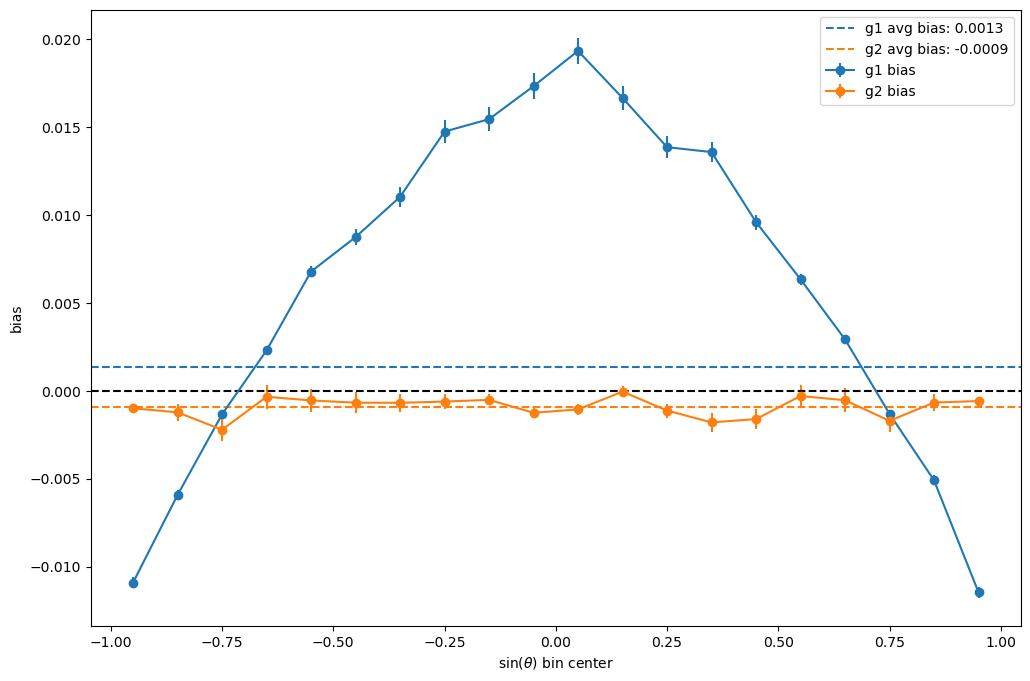

In [57]:
plt.figure(figsize=(12, 8))
plt.errorbar(sin_theta_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(sin_theta_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\sin(\theta)$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_sin_theta.png'), dpi=300, bbox_inches='tight')
plt.show()

In [61]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(len(cos_theta_bin_centers)):
    g1_diff_bin = g1_diff[cos_theta_bin_indices == i]
    g2_diff_bin = g2_diff[cos_theta_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

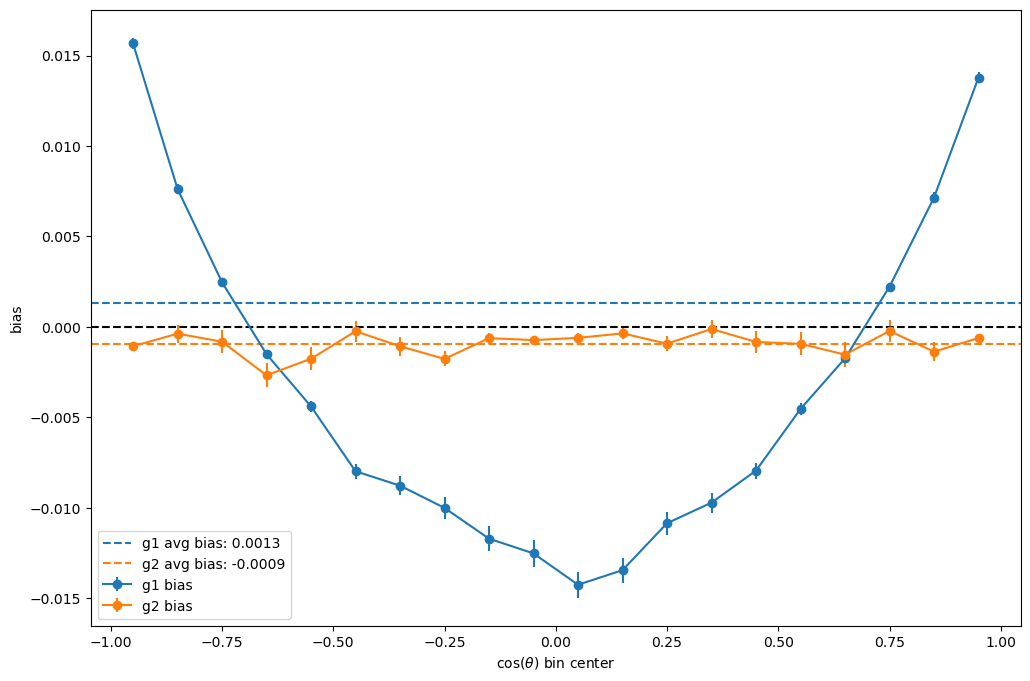

In [62]:
plt.figure(figsize=(12, 8))
plt.errorbar(cos_theta_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(cos_theta_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\cos(\theta)$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_cos_theta.png'), dpi=300, bbox_inches='tight')
plt.show()

In [64]:
sini_bin_centers = np.arange(0, 1, 0.1)+0.05
sini_bin_edges = np.arange(0, 1.01, 0.1)
sini_bin_indices = np.digitize(truths[:, 3], sini_bin_edges) - 1

In [65]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(len(sini_bin_centers)):
    g1_diff_bin = g1_diff[sini_bin_indices == i]
    g2_diff_bin = g2_diff[sini_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

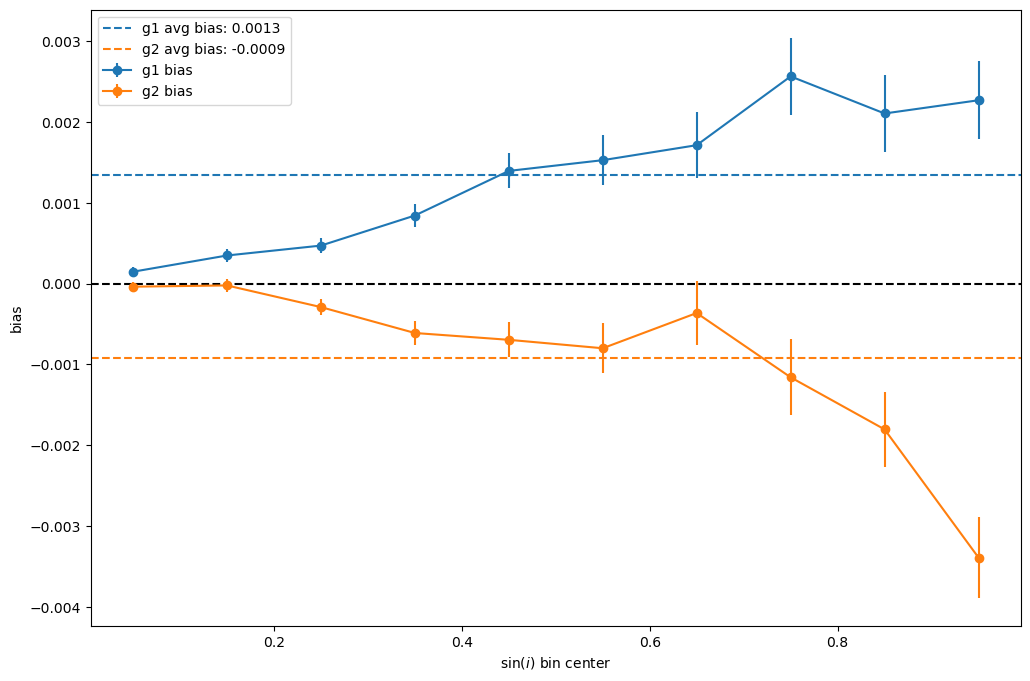

In [66]:
plt.figure(figsize=(12, 8))
plt.errorbar(sini_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(sini_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\sin(i)$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_sini.png'), dpi=300, bbox_inches='tight')
plt.show()

In [76]:
hlr_bin_centers = np.arange(0.0, 3.0, 0.2)+0.1
hlr_bin_edges = np.arange(0.0, 3.01, 0.2)
hlr_bin_indices = np.digitize(truths[:, 7], hlr_bin_edges) - 1
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(len(hlr_bin_centers)):
    g1_diff_bin = g1_diff[hlr_bin_indices == i]
    g2_diff_bin = g2_diff[hlr_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

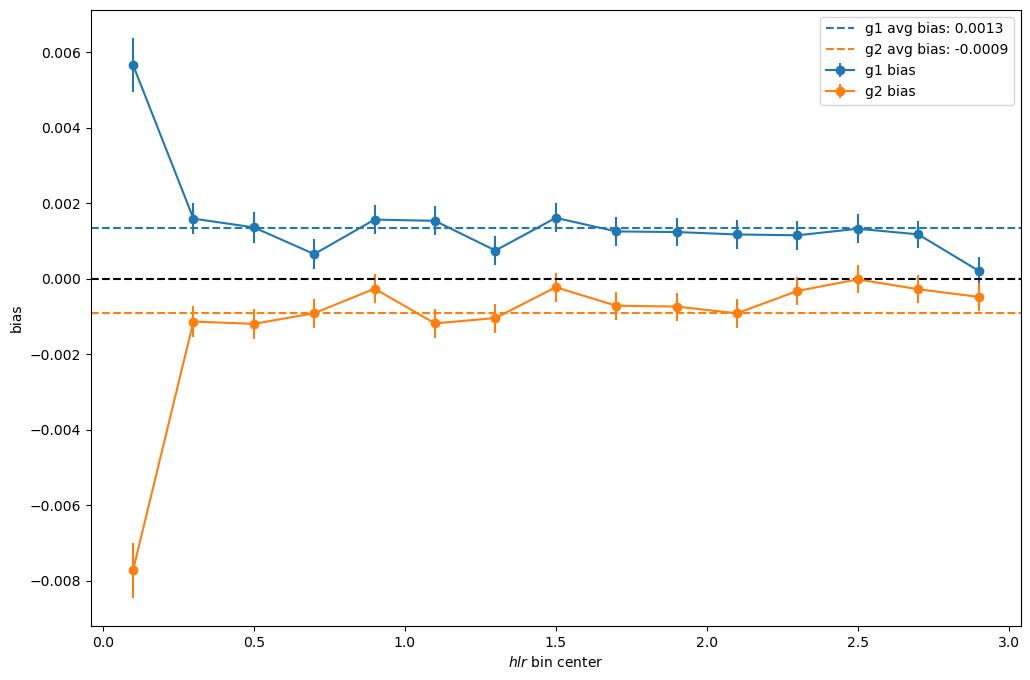

In [77]:
plt.figure(figsize=(12, 8))
plt.errorbar(hlr_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff):.4f}')
plt.errorbar(hlr_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$hlr$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_hlr.png'), dpi=300, bbox_inches='tight')
plt.show()

In [38]:
print('shear additive bias (no tf prior)')
print(np.mean(g1_diff), np.std(g1_diff)/np.sqrt(len(g1_diff)))
print(np.mean(g2_diff), np.std(g2_diff)/np.sqrt(len(g2_diff)))

shear additive bias (no tf prior)
0.0016005856703966855 0.00022764656959998808
-0.0010638651464134454 0.00022654164496496988


In [35]:
print('shear additive bias (w/ tf prior)')
print(np.mean(g1_diff), np.std(g1_diff)/np.sqrt(len(g1_diff)))
print(np.mean(g2_diff), np.std(g2_diff)/np.sqrt(len(g2_diff)))

shear additive bias (w/ tf prior)
0.001557452548108995 0.00018240592510668902
-0.0013300096210092306 0.00018120028758981612


In [10]:
from plots import ParameterContourPlotter

plotter = ParameterContourPlotter(
    model_name=model_name,
    true=truths,
    pred=map_estimates[0],
    pred_tf=map_estimates[1],
    snr=snrs,
    feature_names=config.train['feature_names'],
)

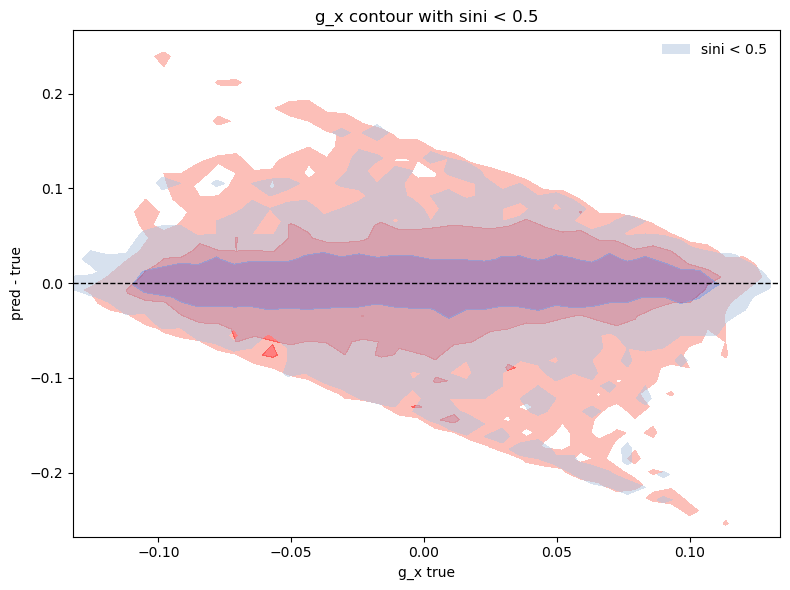

In [15]:
_, _, out_masked = plotter.plot(
    param='gx',
    mask_param='sini',
    masking_value=0.5,
    flip_mask=True,
    use_tf=False,
    nbins=40,
)

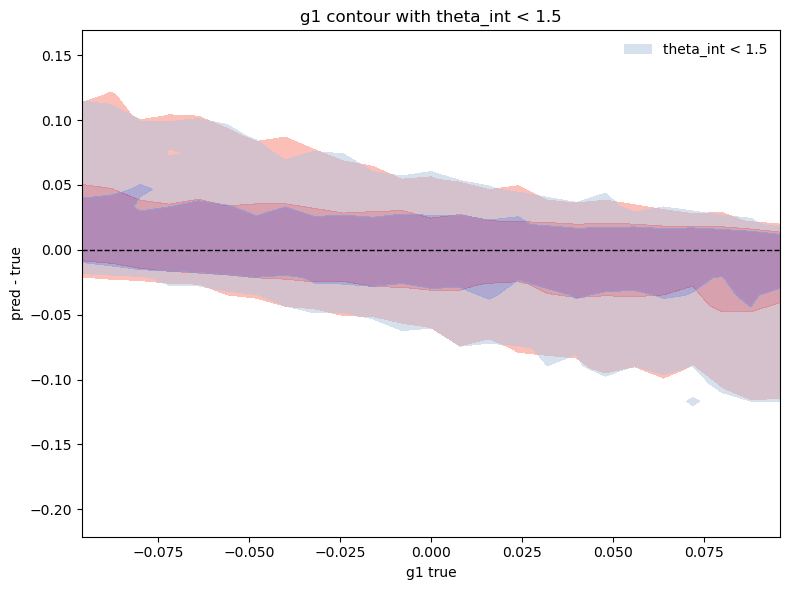

In [11]:
_, _, out_masked = plotter.plot(
    param='g1',
    mask_param='theta_int',
    masking_value=1.5,
    flip_mask=True,
    use_tf=False,
    nbins=25,
)

In [19]:
print(config.par_ranges)

{'g1': [-0.1, 0.1], 'g2': [-0.1, 0.1], 'theta_int': [-3.141592653589793, 3.141592653589793], 'sini': [0.0, 1.0], 'v0': [-30.0, 30.0], 'vcirc': [60.0, 540.0], 'rscale': [0.1, 2.0], 'hlr': [0.1, 3.0]}


In [20]:
par_range_mod = config.par_ranges.copy()
par_range_mod['theta_int'] = [-np.pi, np.pi, True]

In [25]:
snr_target = 1000
snr_tolerance = 10.0
snr_idx = np.where((np.abs(snrs - snr_target) < snr_tolerance) & (np.abs(truths[:, 2]) > 3.05))[0]
print(f'Candidates near SNR={snr_target}:', snr_idx.shape[0])

n_examples = min(5, snr_idx.shape[0])
for i in range(n_examples):
    idx = snr_idx[i]
    print(vcirc_pred[idx], truths[idx, vcirc_idx])
    mode_samples = [samples[0, idx], samples[1, idx]]
    fig, _, _ = make_corner_plot(
        mode_samples,
        truth=truths[idx],
        labels=config.train['feature_names'],
        sample_labels=['no TF prior', 'with TF prior'],
        suptitle=f'Galaxy {idx}, SNR={snrs[idx]:.2f}',
        ranges=par_range_mod
    )
    fig.savefig(join(fig_root, model_name, f'corner_hi_theta_snr_{int(snr_target)}_{i}.png'), dpi=300)
    # fig.savefig(join(fig_root, model_name, f'corner_vcirc_diff_gt_100_{i}.png'), dpi=300)
    plt.close(fig)

Candidates near SNR=1000: 7
439.1978454589844 444.68695
Removed no burn in
Removed no burn in


60.35688400268555 319.3272
Removed no burn in
Removed no burn in
138.8817138671875 147.04265
Removed no burn in
Removed no burn in


60.410369873046875 218.64827
Removed no burn in
Removed no burn in
178.81298828125 405.21967
Removed no burn in
Removed no burn in


In [25]:
sini = np.array(sample_table['sini'])[:ngals]
# sini = np.sin(np.array(sample_table['i'])[:ngals])
sini_mask = sini < 0.5

In [17]:
os.makedirs(join(fig_root, model_name), exist_ok=True)

legend_sini = [
    r'$2\sigma$, $\sin i$ > 0.5',
    r'$1\sigma$, $\sin i$ > 0.5',
    r'$2\sigma$, $\sin i$ < 0.5',
    r'$1\sigma$, $\sin i$ < 0.5',
]

make_g_contour(
    g1_true, g2_true, g1_diff, g2_diff,
    axis='12',
    nbins=25,
    mask=sini_mask,
    anti_mask=True,
    legend_str_list=legend_sini,
    save=True,
    filename=f'g12_contour_sini_split_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

make_g_contour(
    gp_true, gc_true, gp_diff, gc_diff,
    axis='pc',
    nbins=25,
    mask=sini_mask,
    anti_mask=True,
    legend_str_list=legend_sini,
    save=True,
    filename=f'gpc_contour_sini_split_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

plt.close('all')

In [18]:
os.makedirs(join(fig_root, model_name), exist_ok=True)

legend_snr = [
    r'$2\sigma$, $SNR < 250$',
    r'$1\sigma$, $SNR < 250$',
    r'$2\sigma$, $SNR > 250$',
    r'$1\sigma$, $SNR > 250$',
]
snr_mask = snrs[sini_mask] > 250
g1_true_cut, g2_true_cut = g1_true[sini_mask], g2_true[sini_mask]
g1_diff_cut, g2_diff_cut = g1_diff[sini_mask], g2_diff[sini_mask]
gp_true_cut, gc_true_cut = gp_true[sini_mask], gc_true[sini_mask]
gp_diff_cut, gc_diff_cut = gp_diff[sini_mask], gc_diff[sini_mask]

make_g_contour(
    g1_true_cut, g2_true_cut, g1_diff_cut, g2_diff_cut,
    axis='12',
    nbins=25,
    mask=snr_mask,
    anti_mask=True,
    legend_str_list=legend_snr,
    save=True,
    filename=f'g12_contour_snr_split_sini_cut_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

make_g_contour(
    gp_true_cut, gc_true_cut, gp_diff_cut, gc_diff_cut,
    axis='pc',
    nbins=25,
    mask=snr_mask,
    anti_mask=True,
    legend_str_list=legend_snr,
    save=True,
    filename=f'gpc_contour_snr_split_sini_cut_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

plt.close('all')

In [23]:
def binned_bias(x_true, x_diff, nbins=20):
    edges = np.linspace(-0.1, 0.1, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        mask = which == i
        if np.any(mask):
            vals = x_diff[mask]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])

    return centers, mean, err

c1, m1, e1 = binned_bias(g1_true, g1_diff)
c2, m2, e2 = binned_bias(g2_true, g2_diff)
cp, mp, ep = binned_bias(gp_true, gp_diff)
cx, mx, ex = binned_bias(gc_true, gc_diff)

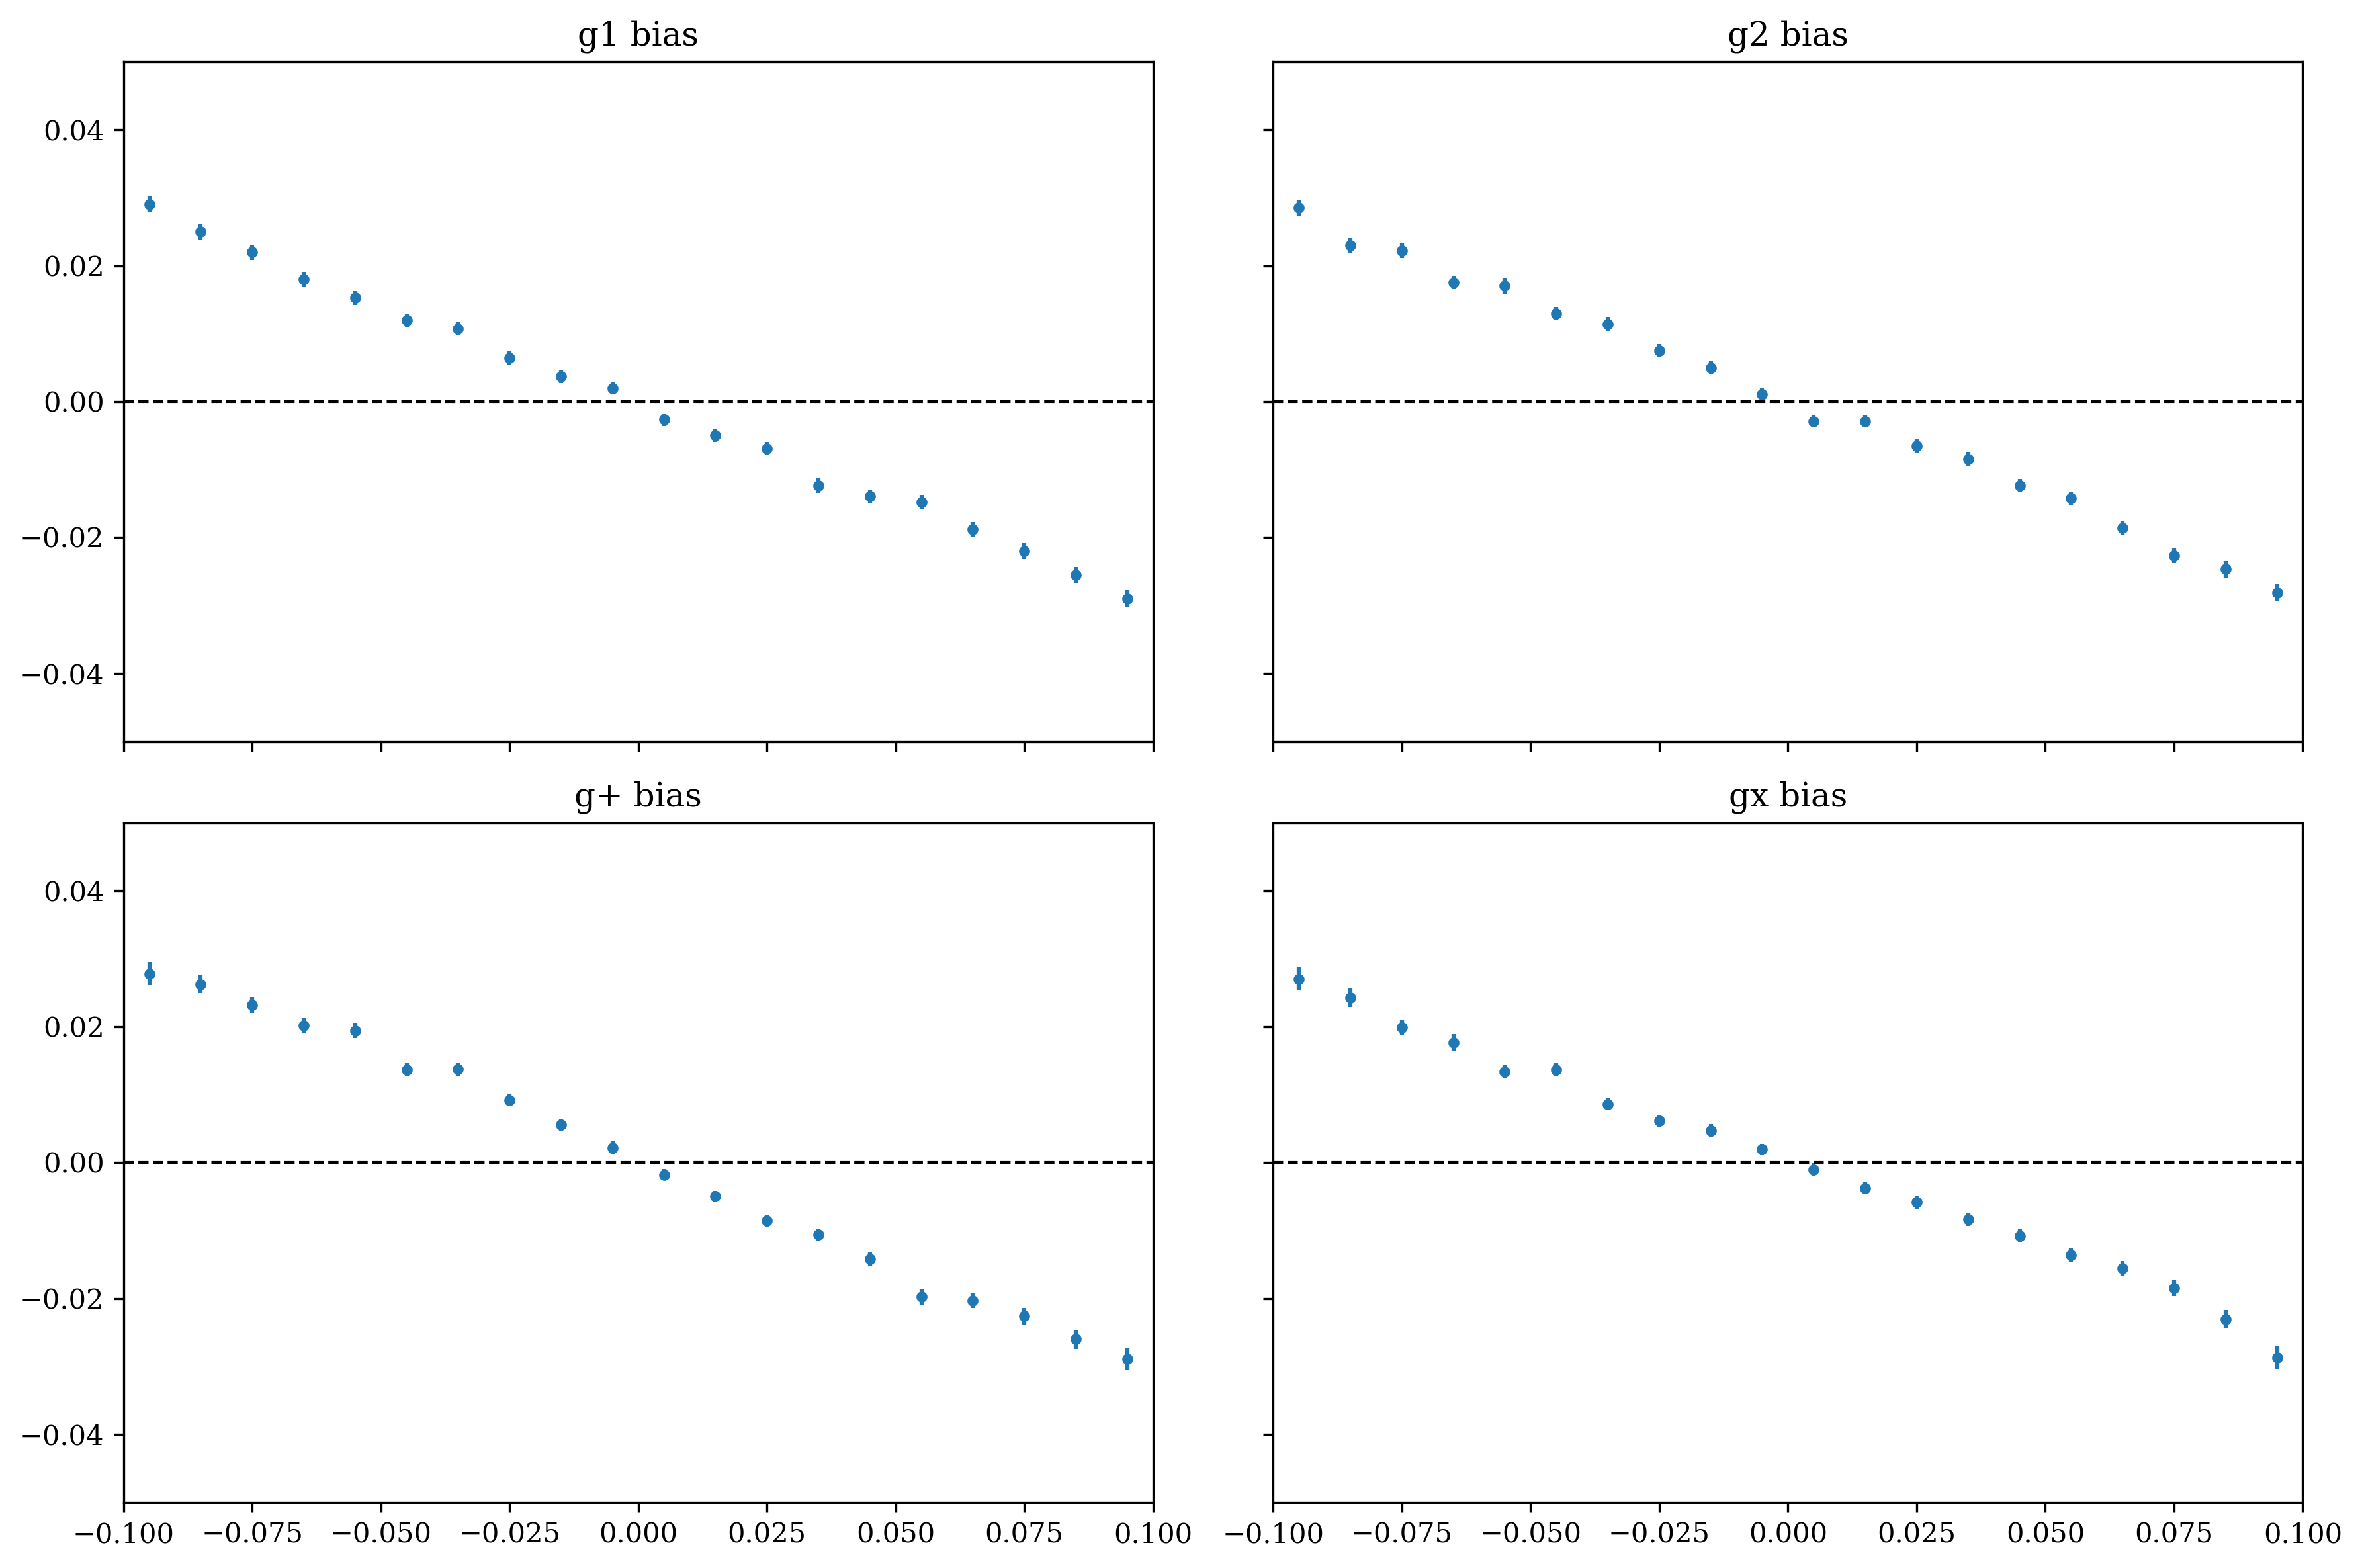

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

axes[0, 0].errorbar(c1, m1, yerr=e1, fmt='o', ms=3)
axes[0, 0].axhline(0.0, ls='--', c='k', lw=1)
axes[0, 0].set_title('g1 bias')

axes[0, 1].errorbar(c2, m2, yerr=e2, fmt='o', ms=3)
axes[0, 1].axhline(0.0, ls='--', c='k', lw=1)
axes[0, 1].set_title('g2 bias')

axes[1, 0].errorbar(cp, mp, yerr=ep, fmt='o', ms=3)
axes[1, 0].axhline(0.0, ls='--', c='k', lw=1)
axes[1, 0].set_title('g+ bias')

axes[1, 1].errorbar(cx, mx, yerr=ex, fmt='o', ms=3)
axes[1, 1].axhline(0.0, ls='--', c='k', lw=1)
axes[1, 1].set_title('gx bias')

for ax in axes.ravel():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.05, 0.05)

plt.tight_layout()
plt.savefig(join(fig_root, model_name, f'bias_summary_{mode_index}.png'), dpi=300)
plt.show()

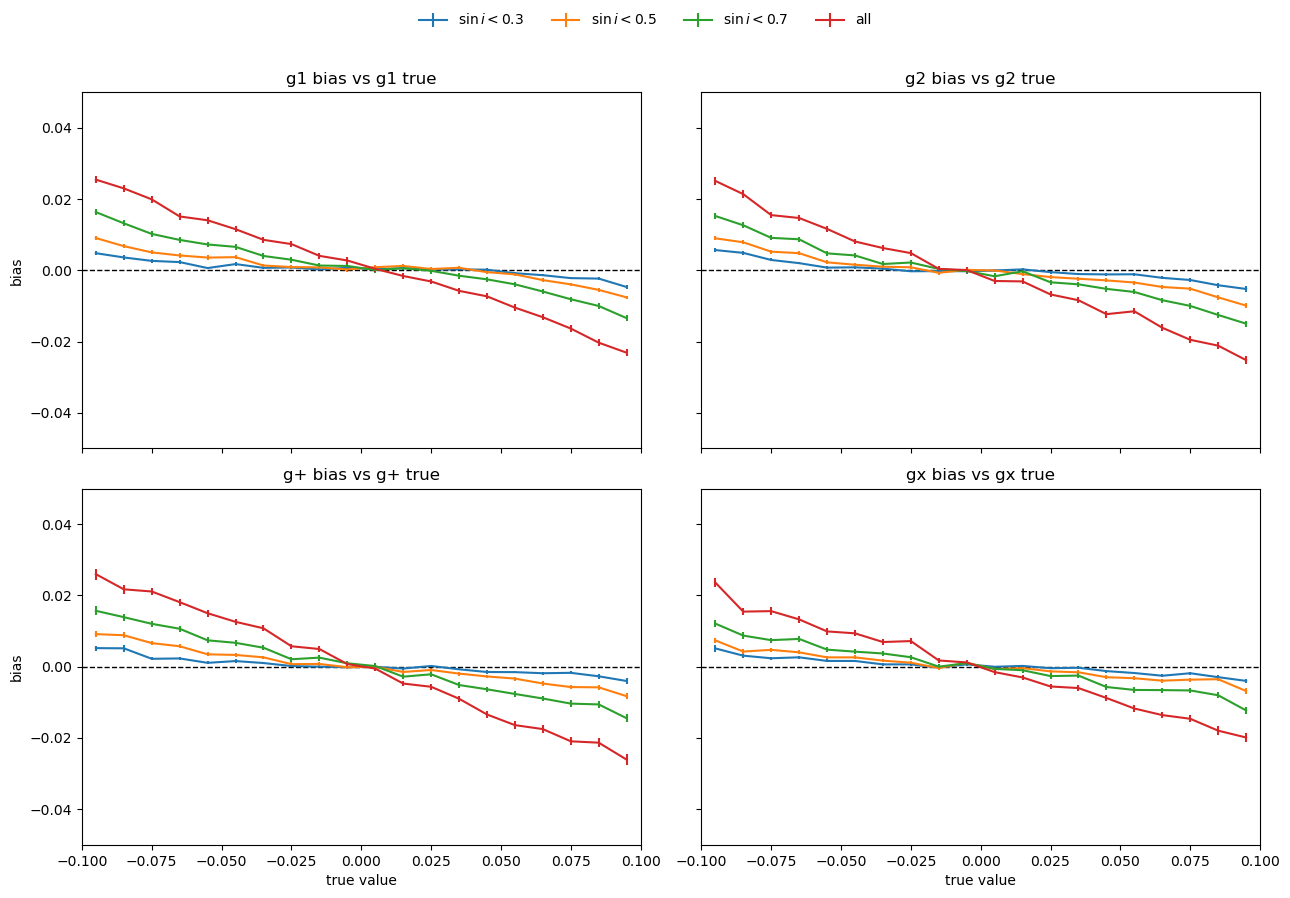

In [29]:
sini_cuts = [0.3, 0.5, 0.7, 1.0]
labels = [r'$\sin i < 0.3$', r'$\sin i < 0.5$', r'$\sin i < 0.7$', 'all']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def binned_bias_masked(x_true, x_diff, mask, nbins=20):
    edges = np.linspace(-0.1, 0.1, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        sel = (which == i) & mask
        if np.any(sel):
            vals = x_diff[sel]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])
    return centers, mean, err

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for cut, label, color in zip(sini_cuts, labels, colors):
    if cut >= 1.0:
        mask = np.ones_like(sini, dtype=bool)
    else:
        mask = sini < cut

    c1, m1, e1 = binned_bias_masked(g1_true, g1_diff, mask)
    c2, m2, e2 = binned_bias_masked(g2_true, g2_diff, mask)
    cp, mp, ep = binned_bias_masked(gp_true, gp_diff, mask)
    cx, mx, ex = binned_bias_masked(gc_true, gc_diff, mask)

    axes[0, 0].errorbar(c1, m1, yerr=e1, lw=1.5, color=color, label=label)
    axes[0, 1].errorbar(c2, m2, yerr=e2, lw=1.5, color=color, label=label)
    axes[1, 0].errorbar(cp, mp, yerr=ep, lw=1.5, color=color, label=label)
    axes[1, 1].errorbar(cx, mx, yerr=ex, lw=1.5, color=color, label=label)

axes[0, 0].set_title('g1 bias vs g1 true')
axes[0, 1].set_title('g2 bias vs g2 true')
axes[1, 0].set_title('g+ bias vs g+ true')
axes[1, 1].set_title('gx bias vs gx true')

for ax in axes.ravel():
    ax.axhline(0.0, ls='--', c='k', lw=1)
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.05, 0.05)

axes[1, 0].set_xlabel('true value')
axes[1, 1].set_xlabel('true value')
axes[0, 0].set_ylabel('bias')
axes[1, 0].set_ylabel('bias')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(join(fig_root, model_name, f'bias_vs_true_sini_cuts_{mode_index}.png'), dpi=300)
plt.show()